# Exploratory Data Analysis (EDA)
## Insurance Risk Analytics - Task 1

This notebook performs comprehensive exploratory data analysis on insurance data to:
- Understand data structure and quality
- Identify patterns in risk and profitability
- Answer key business questions
- Generate actionable insights


In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import sys
import os

# Add src to path - robust path resolution
# Get the project root directory (parent of notebooks directory)
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    # If we're in notebooks directory, go up one level
    project_root = current_dir.parent
else:
    # Otherwise, assume we're at project root
    project_root = current_dir

# Add src directory to Python path
src_path = project_root / 'src'
if src_path.exists():
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
    print(f"✓ Added to path: {src_path}")
else:
    # Try alternative paths
    alt_paths = [
        Path.cwd().parent / 'src',  # If in notebooks, go up
        Path.cwd() / 'src',  # If at root
    ]
    found = False
    for alt_path in alt_paths:
        if alt_path.exists():
            if str(alt_path) not in sys.path:
                sys.path.insert(0, str(alt_path))
            print(f"✓ Added to path (alternative): {alt_path}")
            found = True
            break
    
    if not found:
        print(f"⚠ Warning: Could not find src directory")
        print(f"  Current directory: {Path.cwd()}")
        print(f"  Project root: {project_root}")
        print(f"  Looking for: {src_path}")

# Import custom modules
try:
    from data_loader import load_insurance_data, get_data_info, validate_data
    from eda_utils import (
        calculate_descriptive_stats,
        calculate_loss_ratio,
        calculate_loss_ratio_by_group,
        detect_outliers_iqr,
        calculate_correlation_matrix,
        get_distribution_info
    )
    from visualization import (
        plot_distribution,
        plot_categorical_counts,
        plot_correlation_heatmap,
        plot_boxplot_by_group,
        plot_scatter_with_trend,
        save_figure
    )
    print("✓ Custom modules imported successfully!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print(f"\nDebugging info:")
    print(f"  Current directory: {os.getcwd()}")
    print(f"  Python path entries:")
    for i, p in enumerate(sys.path[:5]):  # Show first 5
        print(f"    {i}: {p}")
    print(f"\n  Checking if src directory exists:")
    print(f"    {project_root / 'src'}: {(project_root / 'src').exists()}")
    print(f"    {Path.cwd().parent / 'src'}: {(Path.cwd().parent / 'src').exists()}")
    raise

# Settings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully!")


✓ Added to path: d:\kifyaAi\insurance-risk-analytics\src
✓ Custom modules imported successfully!
✓ All libraries imported successfully!


## 1. Data Loading and Initial Inspection


In [6]:
# Load the insurance data
df = load_insurance_data("insurance.csv", data_type="raw")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


Data loaded successfully!
Shape: (1338, 7)

First few rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Data Summarization

### 2.1 Data Structure and Types


In [7]:
# Get comprehensive data information
data_info = get_data_info(df)

print("=" * 60)
print("DATA STRUCTURE INFORMATION")
print("=" * 60)
print(f"\nDataset Shape: {data_info['shape']}")
print(f"Rows: {data_info['shape'][0]}, Columns: {data_info['shape'][1]}")
print(f"\nMemory Usage: {data_info['memory_usage'] / 1024**2:.2f} MB")
print(f"\nDuplicate Rows: {data_info['duplicates']}")

print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
dtypes_df = pd.DataFrame({
    'Column': data_info['columns'],
    'Data Type': [str(data_info['dtypes'][col]) for col in data_info['columns']]
})
print(dtypes_df.to_string(index=False))

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing_df = pd.DataFrame({
    'Column': list(data_info['missing_values'].keys()),
    'Missing Count': list(data_info['missing_values'].values()),
    'Missing %': [f"{data_info['missing_percentage'][col]:.2f}%" 
                  for col in data_info['missing_values'].keys()]
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found!")


DATA STRUCTURE INFORMATION

Dataset Shape: (1338, 7)
Rows: 1338, Columns: 7

Memory Usage: 0.25 MB

Duplicate Rows: 1

COLUMN DATA TYPES
  Column Data Type
     age     int64
     sex    object
     bmi   float64
children     int64
  smoker    object
  region    object
 charges   float64

MISSING VALUES
No missing values found!


### 2.2 Descriptive Statistics


In [8]:
# Calculate comprehensive descriptive statistics
desc_stats = calculate_descriptive_stats(df)

print("=" * 60)
print("DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES")
print("=" * 60)
print(desc_stats.round(2))


DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES
              age      bmi  children       charges
count     1338.00  1338.00   1338.00  1.338000e+03
mean        39.21    30.66      1.09  1.327042e+04
median      39.00    30.40      1.00  9.382030e+03
std         14.05     6.10      1.21  1.211001e+04
min         18.00    15.96      0.00  1.121870e+03
max         64.00    53.13      5.00  6.377043e+04
q25         27.00    26.30      0.00  4.740290e+03
q75         51.00    34.69      2.00  1.663991e+04
skewness     0.06     0.28      0.94  1.520000e+00
kurtosis    -1.25    -0.05      0.20  1.610000e+00
variance   197.40    37.19      1.45  1.466524e+08


## 3. Data Quality Assessment


In [9]:
# Validate data quality
validation = validate_data(df)

print("=" * 60)
print("DATA QUALITY VALIDATION")
print("=" * 60)
print(f"Has Missing Values: {validation['has_missing']}")
print(f"Has Duplicates: {validation['has_duplicates']}")
print(f"Empty DataFrame: {validation['empty_dataframe']}")
print(f"\nNumeric Columns ({len(validation['numeric_columns'])}): {validation['numeric_columns']}")
print(f"\nCategorical Columns ({len(validation['categorical_columns'])}): {validation['categorical_columns']}")


DATA QUALITY VALIDATION
Has Missing Values: False
Has Duplicates: True
Empty DataFrame: False

Numeric Columns (4): ['age', 'bmi', 'children', 'charges']

Categorical Columns (3): ['sex', 'smoker', 'region']


## 4. Univariate Analysis

### 4.1 Distribution of Numerical Variables


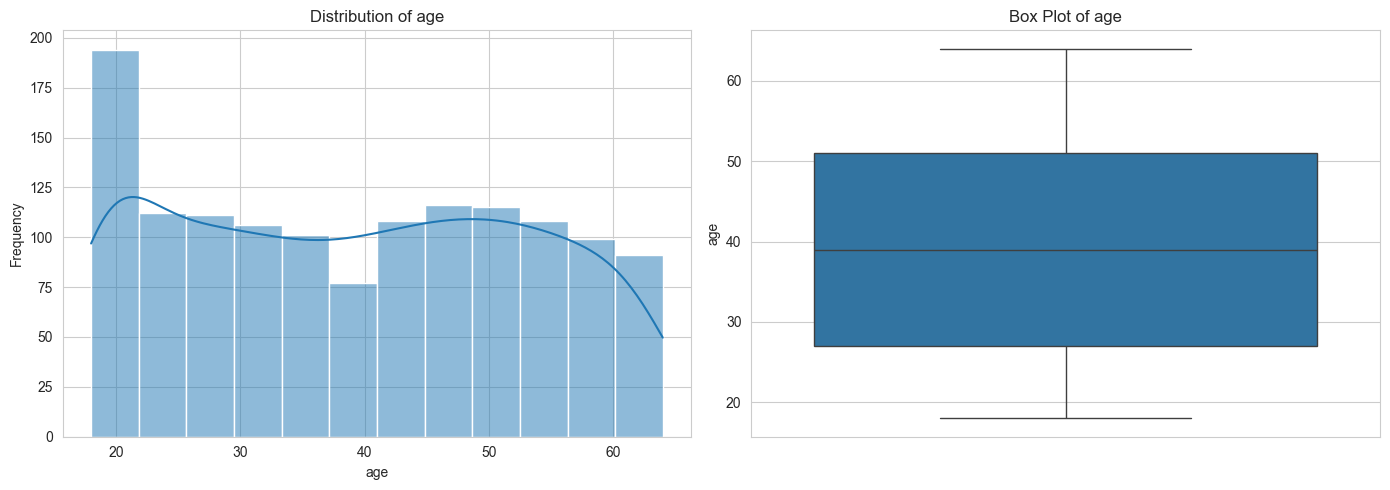


age Distribution Info:
  Mean: 39.21
  Median: 39.00
  Std Dev: 14.05
  Skewness: 0.06
  Kurtosis: -1.25
  Normal Distribution: False
------------------------------------------------------------


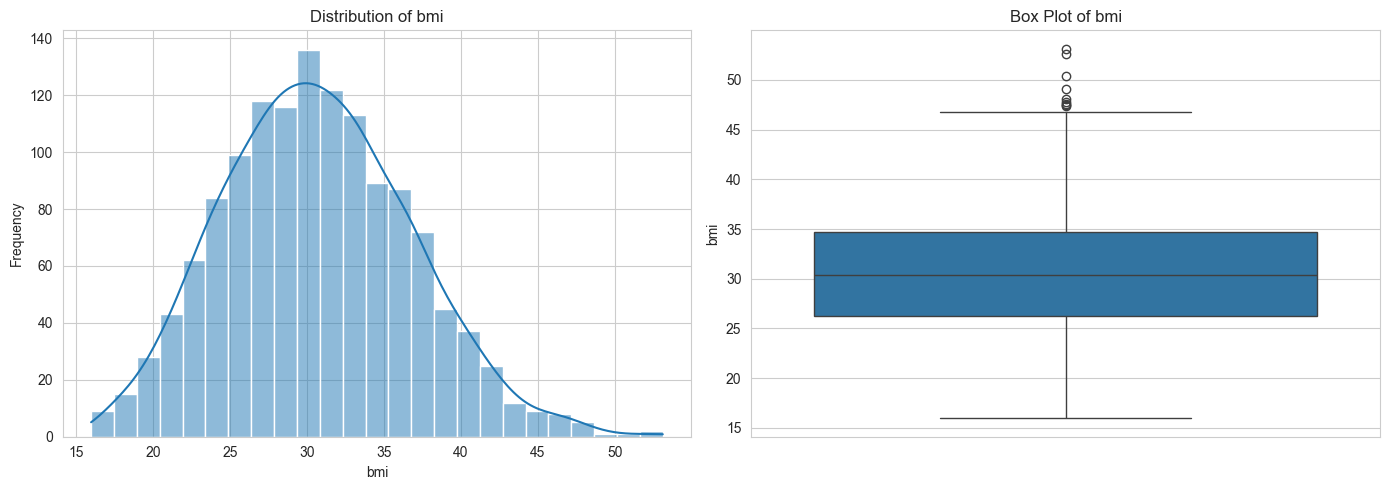


bmi Distribution Info:
  Mean: 30.66
  Median: 30.40
  Std Dev: 6.10
  Skewness: 0.28
  Kurtosis: -0.05
  Normal Distribution: False
------------------------------------------------------------


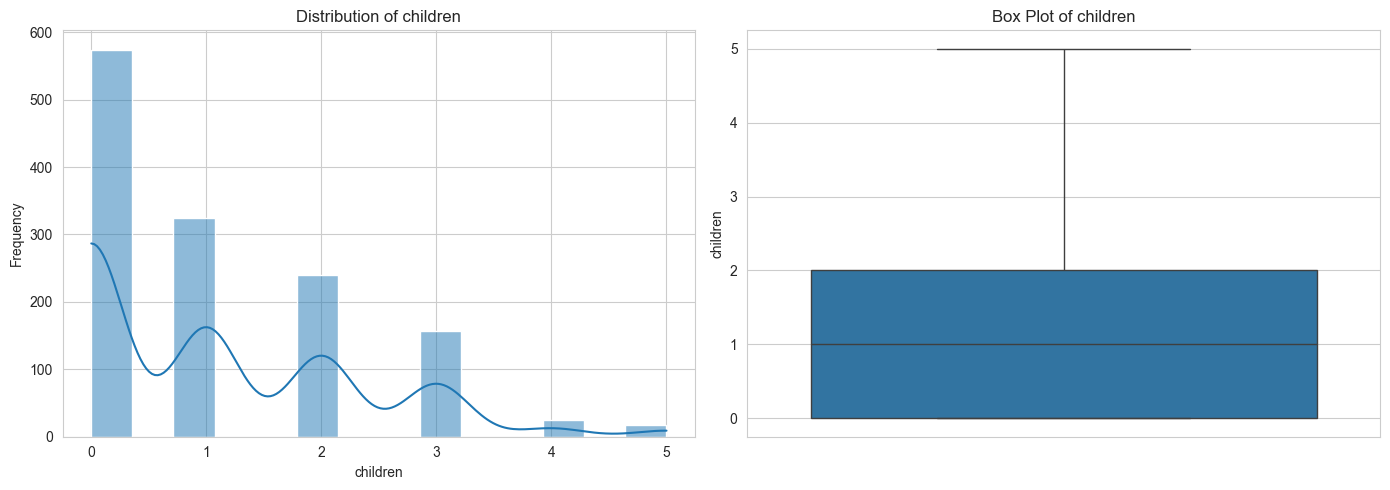


children Distribution Info:
  Mean: 1.09
  Median: 1.00
  Std Dev: 1.21
  Skewness: 0.94
  Kurtosis: 0.20
  Normal Distribution: False
------------------------------------------------------------


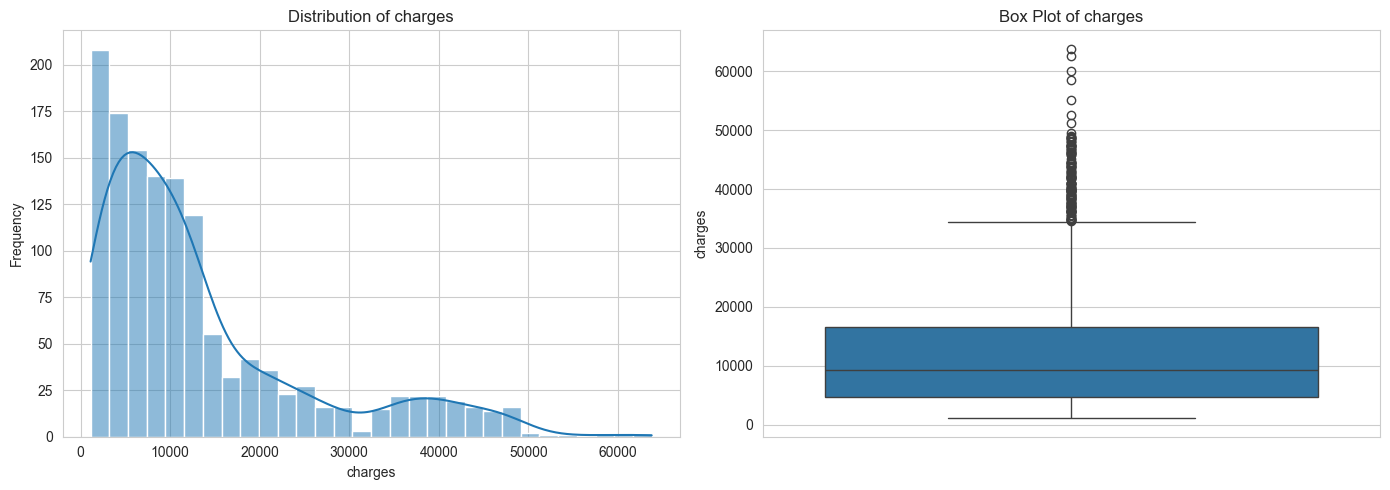


charges Distribution Info:
  Mean: 13270.42
  Median: 9382.03
  Std Dev: 12110.01
  Skewness: 1.52
  Kurtosis: 1.61
  Normal Distribution: False
------------------------------------------------------------


In [11]:
# Plot distributions for all numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    fig = plot_distribution(df, col, figsize=(14, 5))
    plt.show()
    
    # Print distribution info
    dist_info = get_distribution_info(df, col)
    print(f"\n{col} Distribution Info:")
    print(f"  Mean: {dist_info['mean']:.2f}")
    print(f"  Median: {dist_info['median']:.2f}")
    print(f"  Std Dev: {dist_info['std']:.2f}")
    print(f"  Skewness: {dist_info['skewness']:.2f}")
    print(f"  Kurtosis: {dist_info['kurtosis']:.2f}")
    print(f"  Normal Distribution: {dist_info['is_normal']}")
    print("-" * 60)


### 4.2 Distribution of Categorical Variables


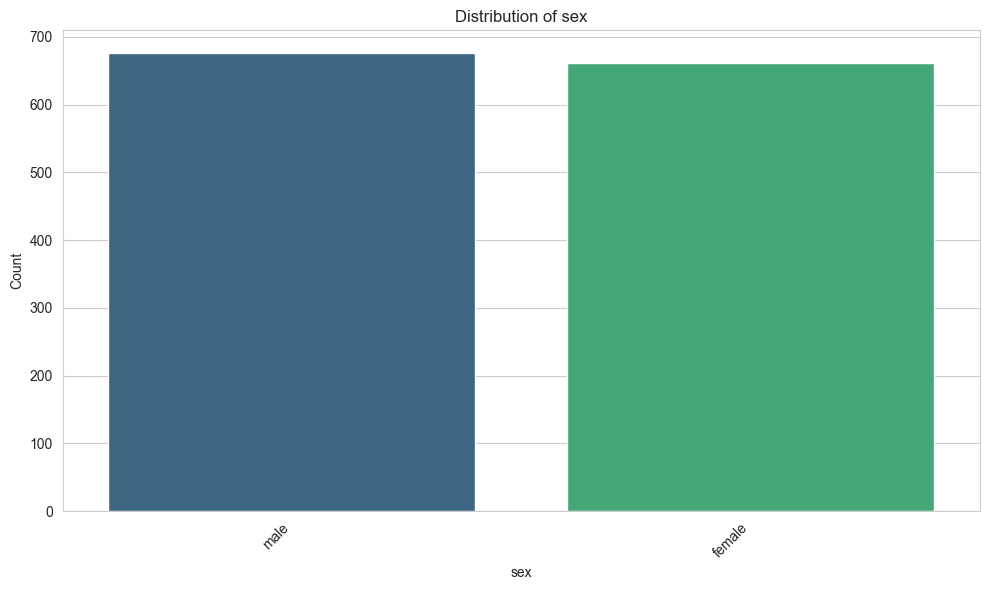


sex Value Counts:
sex
male      676
female    662
Name: count, dtype: int64
------------------------------------------------------------


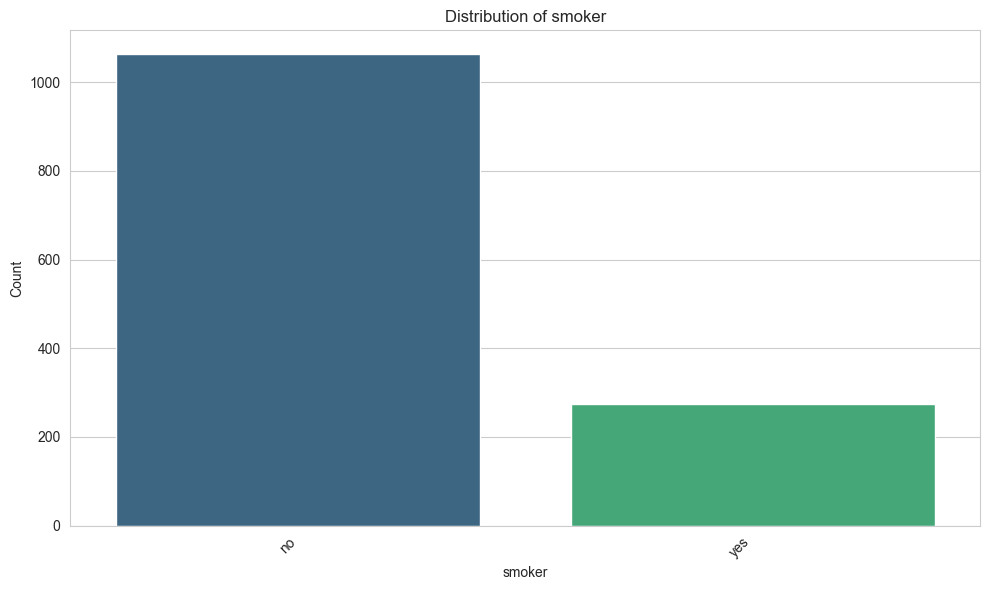


smoker Value Counts:
smoker
no     1064
yes     274
Name: count, dtype: int64
------------------------------------------------------------


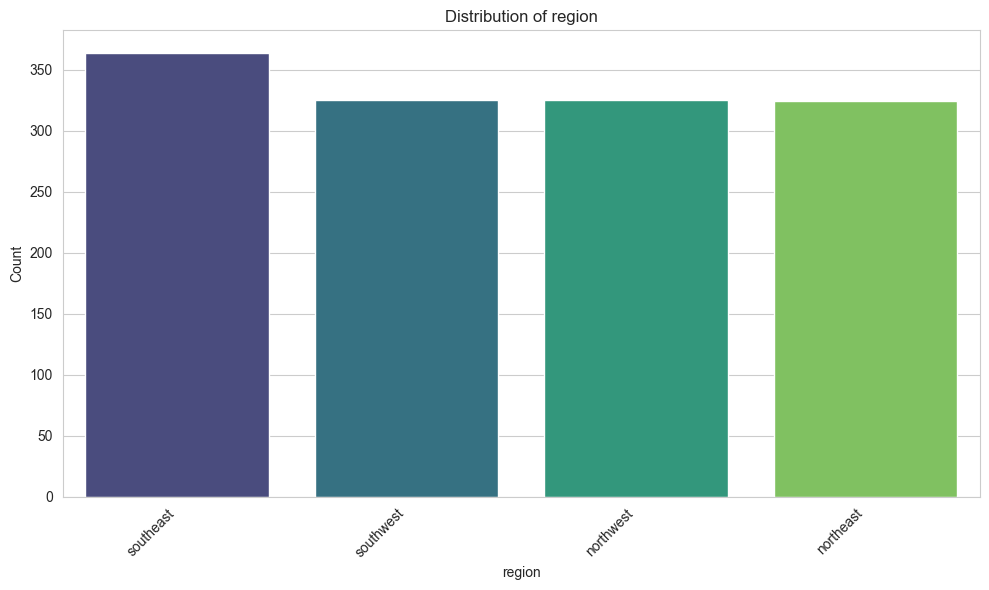


region Value Counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
------------------------------------------------------------


In [13]:
# Plot bar charts for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    fig = plot_categorical_counts(df, col, figsize=(10, 6))
    plt.show()
    
    # Print value counts
    print(f"\n{col} Value Counts:")
    print(df[col].value_counts())
    print("-" * 60)


## 5. Bivariate and Multivariate Analysis

### 5.1 Correlation Analysis


Correlation Matrix:
            age    bmi  children  charges
age       1.000  0.109     0.042    0.299
bmi       0.109  1.000     0.013    0.198
children  0.042  0.013     1.000    0.068
charges   0.299  0.198     0.068    1.000
Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\correlation_heatmap.png


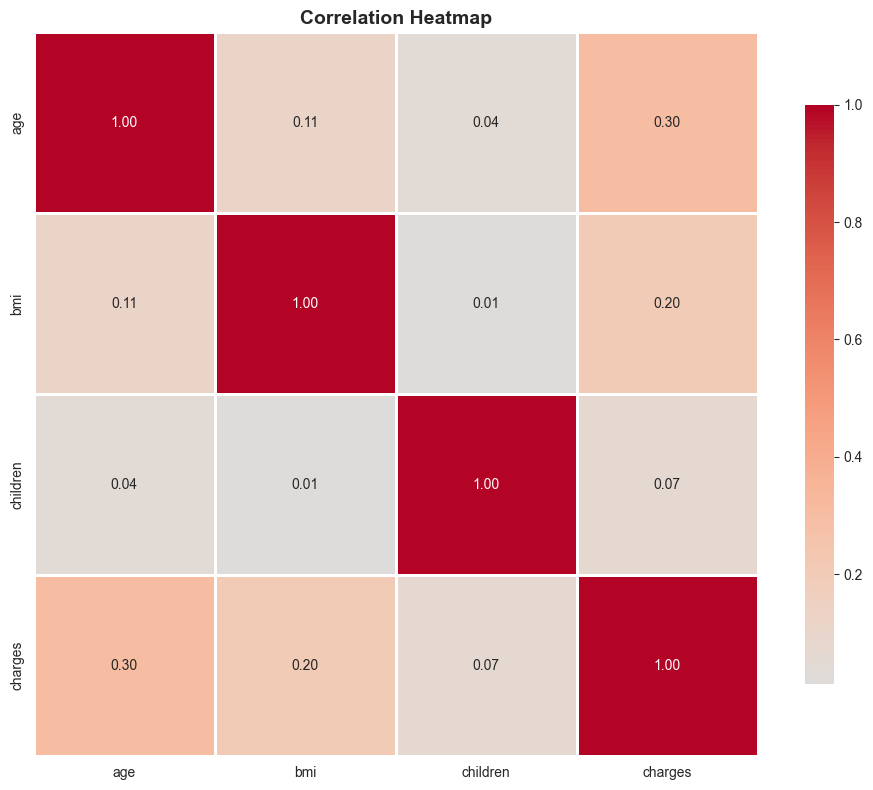

In [14]:
# Calculate and visualize correlation matrix
corr_matrix = calculate_correlation_matrix(df)
print("Correlation Matrix:")
print(corr_matrix.round(3))

# Plot correlation heatmap
fig = plot_correlation_heatmap(df, figsize=(10, 8), save=True)
plt.show()


### 5.2 Relationships Between Key Variables


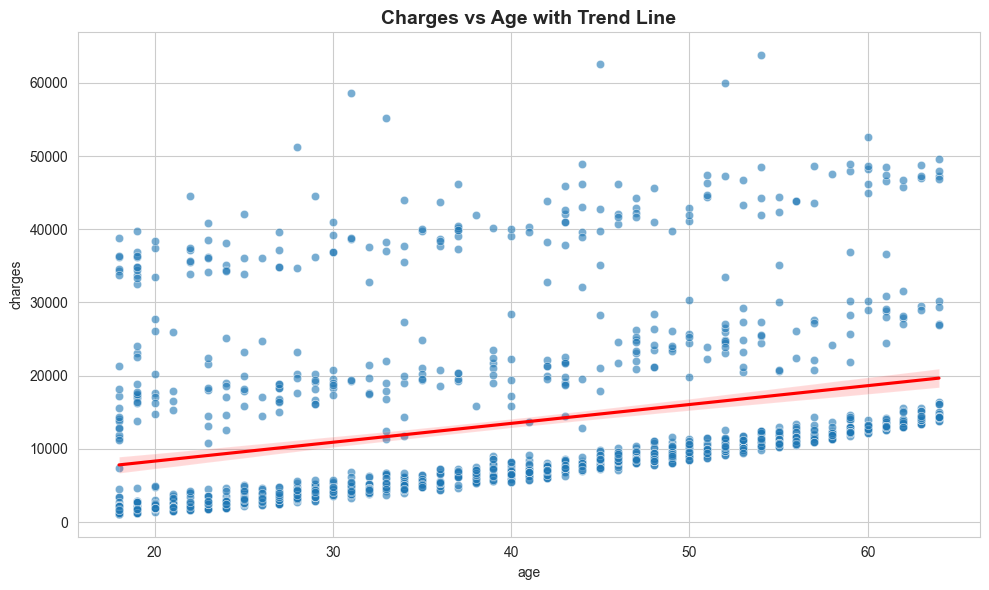

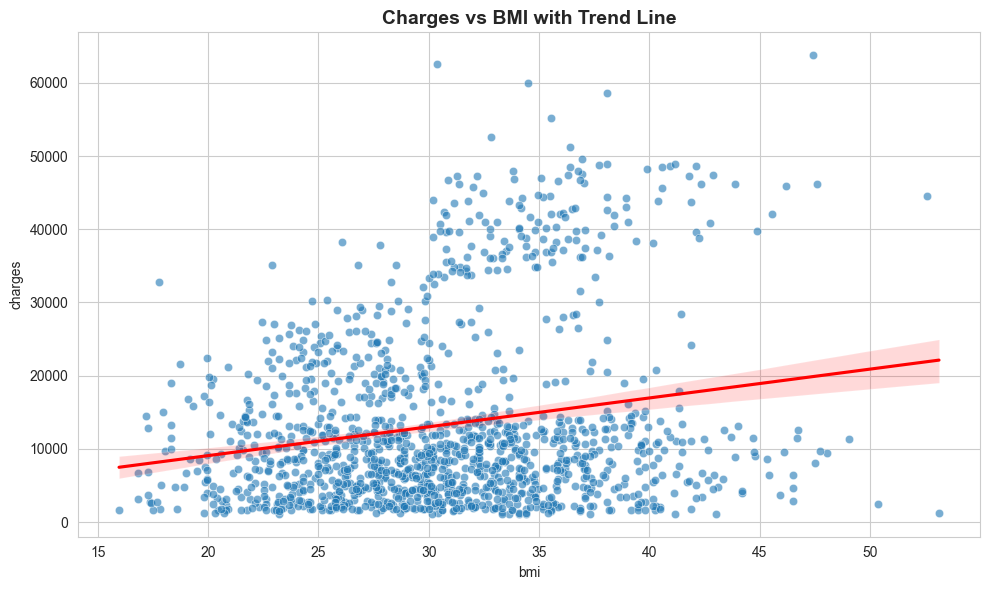

In [12]:
# Explore relationships between numerical variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) >= 2:
    # Create scatter plots for key relationships
    # Example: charges vs age, charges vs bmi
    if 'charges' in numeric_cols and 'age' in numeric_cols:
        fig = plot_scatter_with_trend(df, 'age', 'charges', figsize=(10, 6))
        plt.title('Charges vs Age with Trend Line', fontsize=14, fontweight='bold')
        plt.show()
    
    if 'charges' in numeric_cols and 'bmi' in numeric_cols:
        fig = plot_scatter_with_trend(df, 'bmi', 'charges', figsize=(10, 6))
        plt.title('Charges vs BMI with Trend Line', fontsize=14, fontweight='bold')
        plt.show()


## 6. Geographic and Group Analysis

### 6.1 Analysis by Region/Province


Statistics by Region:
      region         total          mean        median  count           std
0  northeast  4.343669e+06  13406.384516  10057.652025    324  11255.803066
1  northwest  4.035712e+06  12417.575374   8965.795750    325  11072.276928
2  southeast  5.363690e+06  14735.411438   9294.131950    364  13971.098589
3  southwest  4.012755e+06  12346.937377   8798.593000    325  11557.179101
Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\charges_by_region.png


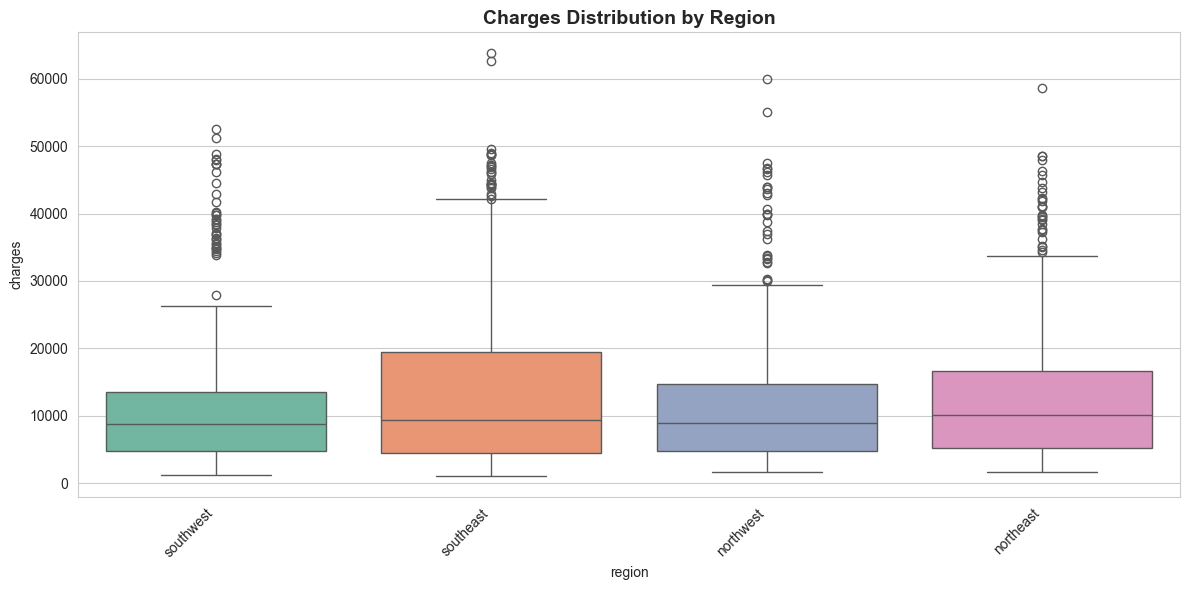

Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\mean_charges_by_region.png


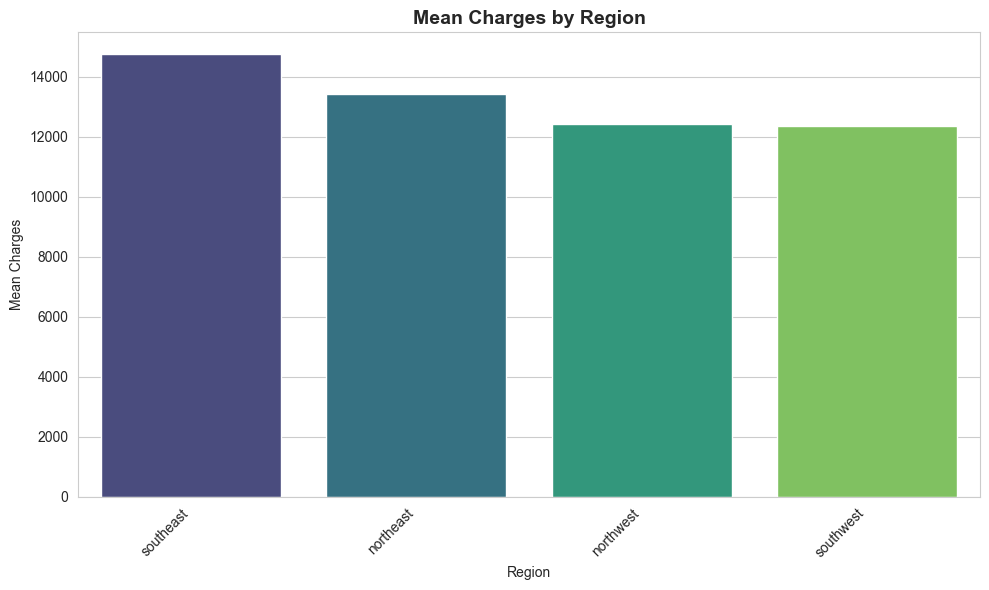

In [15]:
# Analyze by region (if available)
if 'region' in df.columns:
    # Calculate statistics by region
    region_stats = calculate_loss_ratio_by_group(df, 'region', 'charges')
    print("Statistics by Region:")
    print(region_stats)
    
    # Visualize charges by region
    fig = plot_boxplot_by_group(df, 'charges', 'region', figsize=(12, 6), save=True, 
                                filename='charges_by_region.png')
    plt.title('Charges Distribution by Region', fontsize=14, fontweight='bold')
    plt.show()
    
    # Bar plot of mean charges by region
    fig, ax = plt.subplots(figsize=(10, 6))
    region_means = df.groupby('region')['charges'].mean().sort_values(ascending=False)
    sns.barplot(x=region_means.index, y=region_means.values, ax=ax, palette='viridis')
    ax.set_title('Mean Charges by Region', fontsize=14, fontweight='bold')
    ax.set_xlabel('Region')
    ax.set_ylabel('Mean Charges')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_figure(fig, 'mean_charges_by_region.png')
    plt.show()


### 6.2 Analysis by Gender


Statistics by Gender:
      sex         total          mean      median  count           std
0  female  8.321061e+06  12569.578844  9412.96250    662  11128.703801
1    male  9.434764e+06  13956.751178  9369.61575    676  12971.025915
Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\charges_by_gender.png


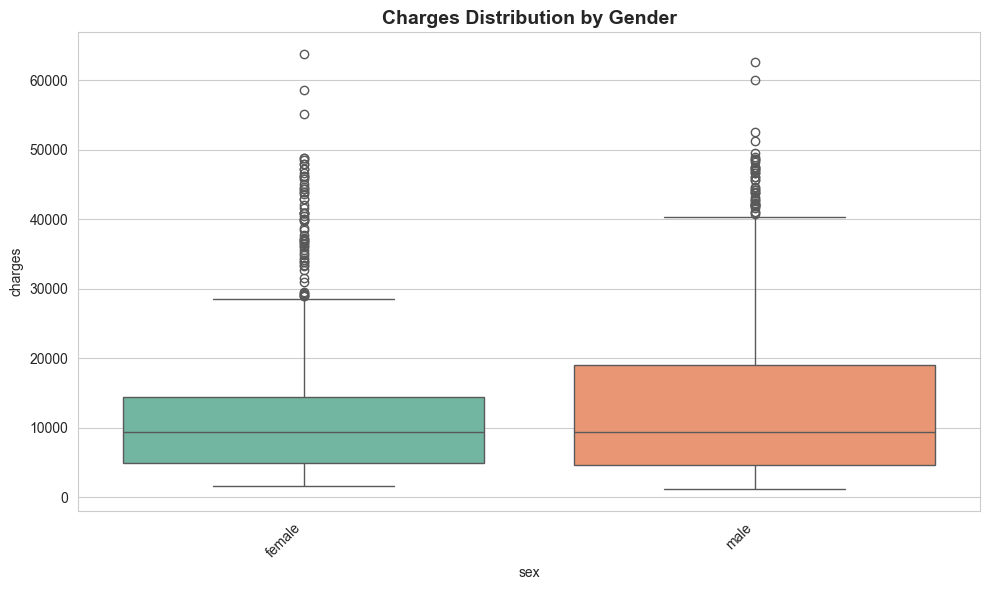

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
# Analyze by gender (if available)
if 'sex' in df.columns or 'gender' in df.columns:
    gender_col = 'sex' if 'sex' in df.columns else 'gender'
    
    # Calculate statistics by gender
    gender_stats = calculate_loss_ratio_by_group(df, gender_col, 'charges')
    print("Statistics by Gender:")
    print(gender_stats)
    
    # Visualize charges by gender
    fig = plot_boxplot_by_group(df, 'charges', gender_col, figsize=(10, 6), save=True,
                                filename='charges_by_gender.png')
    plt.title('Charges Distribution by Gender', fontsize=14, fontweight='bold')
    plt.show()
    
    # Statistical test for difference
    from scipy import stats
    # Fix: Get charges values, not gender values
    groups = [group['charges'].values for name, group in df.groupby(gender_col)]
    if len(groups) == 2:
        stat, p_value = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        print(f"\nMann-Whitney U Test (Gender difference):")
        print(f"  Statistic: {stat:.2f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Significant difference: {'Yes' if p_value < 0.05 else 'No'}")


## 7. Outlier Detection


OUTLIER DETECTION (IQR Method)

age:
  Q1: 27.00
  Q3: 51.00
  IQR: 24.00
  Lower Bound: -9.00
  Upper Bound: 87.00
  Outlier Count: 0 (0.00%)
Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\outliers_age.png


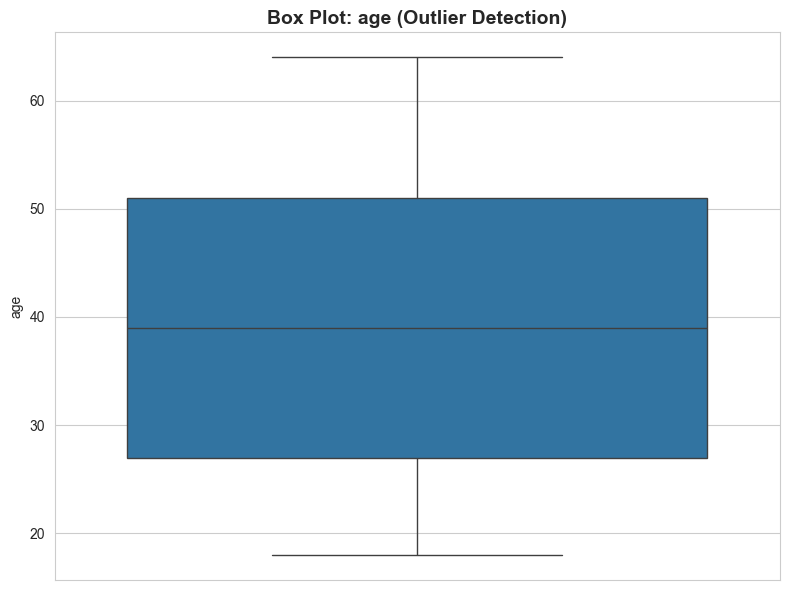


bmi:
  Q1: 26.30
  Q3: 34.69
  IQR: 8.40
  Lower Bound: 13.70
  Upper Bound: 47.29
  Outlier Count: 9 (0.67%)
Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\outliers_bmi.png


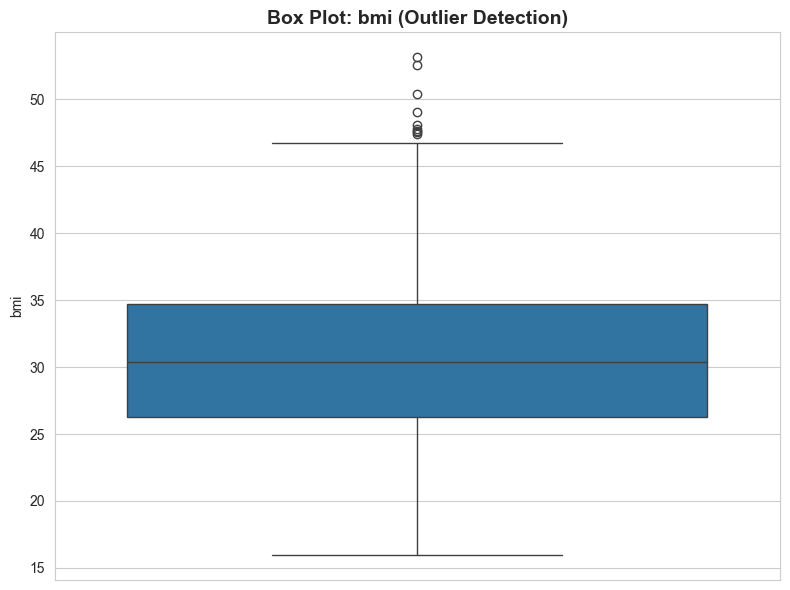


children:
  Q1: 0.00
  Q3: 2.00
  IQR: 2.00
  Lower Bound: -3.00
  Upper Bound: 5.00
  Outlier Count: 0 (0.00%)
Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\outliers_children.png


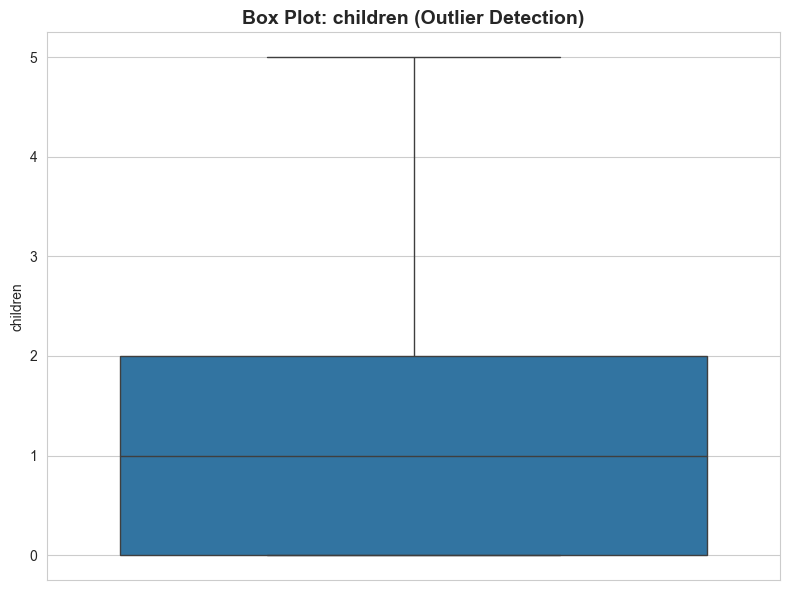


charges:
  Q1: 4740.29
  Q3: 16639.91
  IQR: 11899.63
  Lower Bound: -13109.15
  Upper Bound: 34489.35
  Outlier Count: 139 (10.39%)
Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\outliers_charges.png


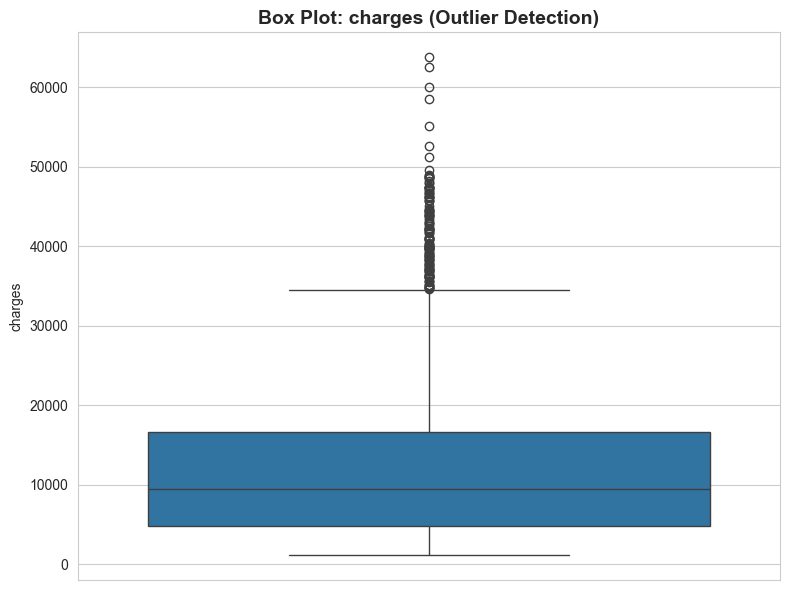


OUTLIER SUMMARY
  Column  Outlier Count  Outlier %
     age              0   0.000000
     bmi              9   0.672646
children              0   0.000000
 charges            139  10.388640


In [17]:
# Detect outliers in key numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 60)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 60)

outlier_summary = []

for col in numeric_cols:
    outliers, stats_dict = detect_outliers_iqr(df, col)
    
    print(f"\n{col}:")
    print(f"  Q1: {stats_dict['Q1']:.2f}")
    print(f"  Q3: {stats_dict['Q3']:.2f}")
    print(f"  IQR: {stats_dict['IQR']:.2f}")
    print(f"  Lower Bound: {stats_dict['lower_bound']:.2f}")
    print(f"  Upper Bound: {stats_dict['upper_bound']:.2f}")
    print(f"  Outlier Count: {stats_dict['outlier_count']} ({stats_dict['outlier_percentage']:.2f}%)")
    
    outlier_summary.append({
        'Column': col,
        'Outlier Count': stats_dict['outlier_count'],
        'Outlier %': stats_dict['outlier_percentage']
    })
    
    # Create box plot for visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f'Box Plot: {col} (Outlier Detection)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_figure(fig, f'outliers_{col}.png')
    plt.show()

# Summary table
outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "=" * 60)
print("OUTLIER SUMMARY")
print("=" * 60)
print(outlier_df.to_string(index=False))


## 8. Answering Key Business Questions

### 8.1 Loss Ratio Analysis


In [18]:
# Calculate loss ratio (adapting to available data)
# Note: For this dataset, we'll analyze charges as the key financial metric

print("=" * 60)
print("FINANCIAL METRICS ANALYSIS")
print("=" * 60)

# Overall statistics
overall_stats = {
    'Total Charges': df['charges'].sum(),
    'Mean Charges': df['charges'].mean(),
    'Median Charges': df['charges'].median(),
    'Std Charges': df['charges'].std(),
}

print("\nOverall Portfolio Statistics:")
for key, value in overall_stats.items():
    print(f"  {key}: ${value:,.2f}")

# Loss ratio by region (if available)
if 'region' in df.columns:
    print("\n" + "-" * 60)
    print("Charges Statistics by Region:")
    print("-" * 60)
    region_analysis = df.groupby('region')['charges'].agg(['sum', 'mean', 'median', 'count'])
    region_analysis.columns = ['Total', 'Mean', 'Median', 'Count']
    print(region_analysis.round(2))
    
    # Calculate "loss ratio" equivalent (mean charges relative to overall mean)
    overall_mean = df['charges'].mean()
    region_analysis['Ratio_to_Overall'] = region_analysis['Mean'] / overall_mean
    print("\nMean Charges Ratio (relative to overall mean):")
    print(region_analysis[['Mean', 'Ratio_to_Overall']].round(3))


FINANCIAL METRICS ANALYSIS

Overall Portfolio Statistics:
  Total Charges: $17,755,824.99
  Mean Charges: $13,270.42
  Median Charges: $9,382.03
  Std Charges: $12,110.01

------------------------------------------------------------
Charges Statistics by Region:
------------------------------------------------------------
                Total      Mean    Median  Count
region                                          
northeast  4343668.58  13406.38  10057.65    324
northwest  4035712.00  12417.58   8965.80    325
southeast  5363689.76  14735.41   9294.13    364
southwest  4012754.65  12346.94   8798.59    325

Mean Charges Ratio (relative to overall mean):
                Mean  Ratio_to_Overall
region                                
northeast  13406.385             1.010
northwest  12417.575             0.936
southeast  14735.411             1.110
southwest  12346.937             0.930


### 8.2 Temporal Trends (if date column available)


In [19]:
# Check for temporal columns and analyze trends
# Note: This dataset may not have temporal columns, but we'll check

temporal_cols = [col for col in df.columns if 'date' in col.lower() or 'month' in col.lower() or 'time' in col.lower()]

if temporal_cols:
    print(f"Temporal columns found: {temporal_cols}")
    # Add temporal analysis here
else:
    print("No temporal columns found in this dataset.")
    print("For temporal analysis, ensure TransactionMonth or similar column exists.")


No temporal columns found in this dataset.
For temporal analysis, ensure TransactionMonth or similar column exists.


## 9. Creative Visualizations - Key Insights

### Visualization 1: Comprehensive Risk Profile


Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\creative_viz1_risk_profile.png


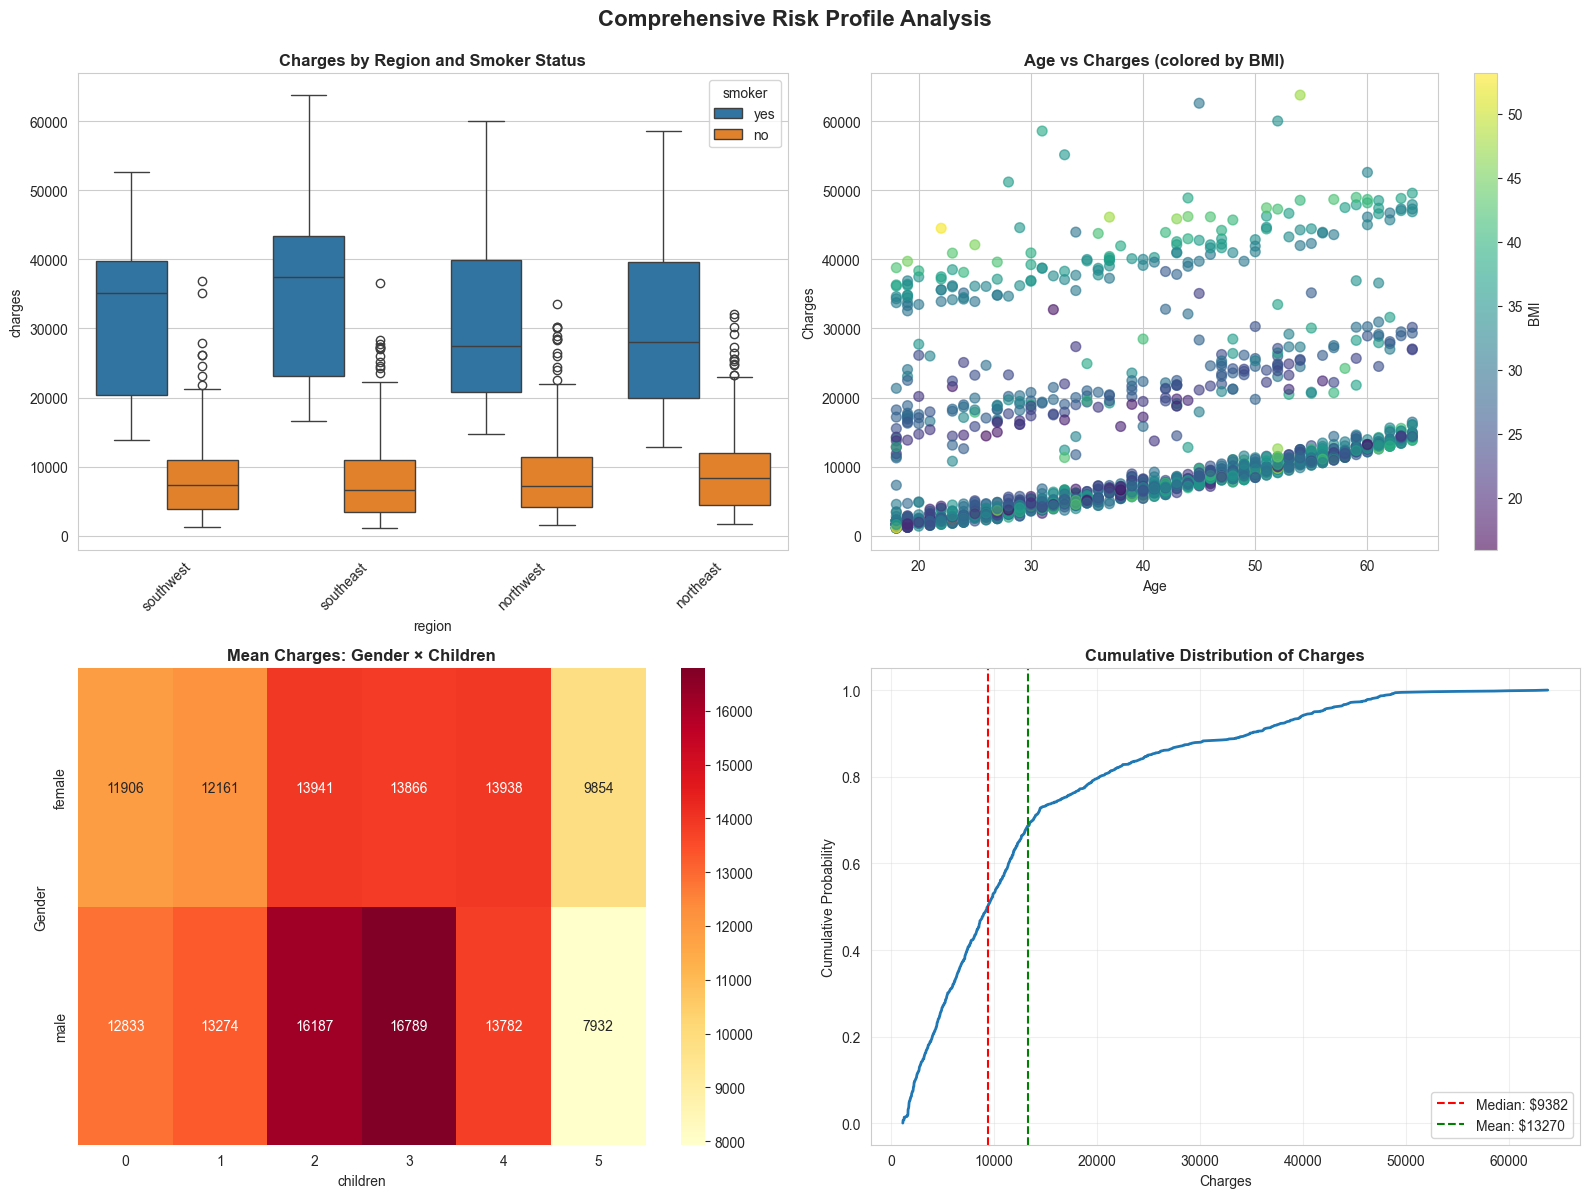

In [20]:
# CREATIVE VISUALIZATION 1: Multi-panel risk profile
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Charges distribution by region and smoker status
if 'region' in df.columns and 'smoker' in df.columns:
    sns.boxplot(data=df, x='region', y='charges', hue='smoker', ax=axes[0, 0])
    axes[0, 0].set_title('Charges by Region and Smoker Status', fontsize=12, fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)

# Panel 2: Age distribution colored by charges
if 'age' in df.columns:
    scatter = axes[0, 1].scatter(df['age'], df['charges'], 
                                 c=df['bmi'] if 'bmi' in df.columns else df['charges'],
                                 cmap='viridis', alpha=0.6, s=50)
    axes[0, 1].set_xlabel('Age')
    axes[0, 1].set_ylabel('Charges')
    axes[0, 1].set_title('Age vs Charges (colored by BMI)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=axes[0, 1], label='BMI' if 'bmi' in df.columns else 'Charges')

# Panel 3: Charges distribution by gender and children
if 'sex' in df.columns and 'children' in df.columns:
    df_grouped = df.groupby(['sex', 'children'])['charges'].mean().reset_index()
    pivot_data = df_grouped.pivot(index='sex', columns='children', values='charges')
    sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1, 0])
    axes[1, 0].set_title('Mean Charges: Gender × Children', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Gender')

# Panel 4: Cumulative distribution of charges
if 'charges' in df.columns:
    sorted_charges = np.sort(df['charges'])
    cumulative = np.arange(1, len(sorted_charges) + 1) / len(sorted_charges)
    axes[1, 1].plot(sorted_charges, cumulative, linewidth=2)
    axes[1, 1].axvline(df['charges'].median(), color='r', linestyle='--', label=f'Median: ${df["charges"].median():.0f}')
    axes[1, 1].axvline(df['charges'].mean(), color='g', linestyle='--', label=f'Mean: ${df["charges"].mean():.0f}')
    axes[1, 1].set_xlabel('Charges')
    axes[1, 1].set_ylabel('Cumulative Probability')
    axes[1, 1].set_title('Cumulative Distribution of Charges', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comprehensive Risk Profile Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
save_figure(fig, 'creative_viz1_risk_profile.png')
plt.show()


### Visualization 2: Demographic Risk Patterns


Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\creative_viz2_demographic_patterns.png


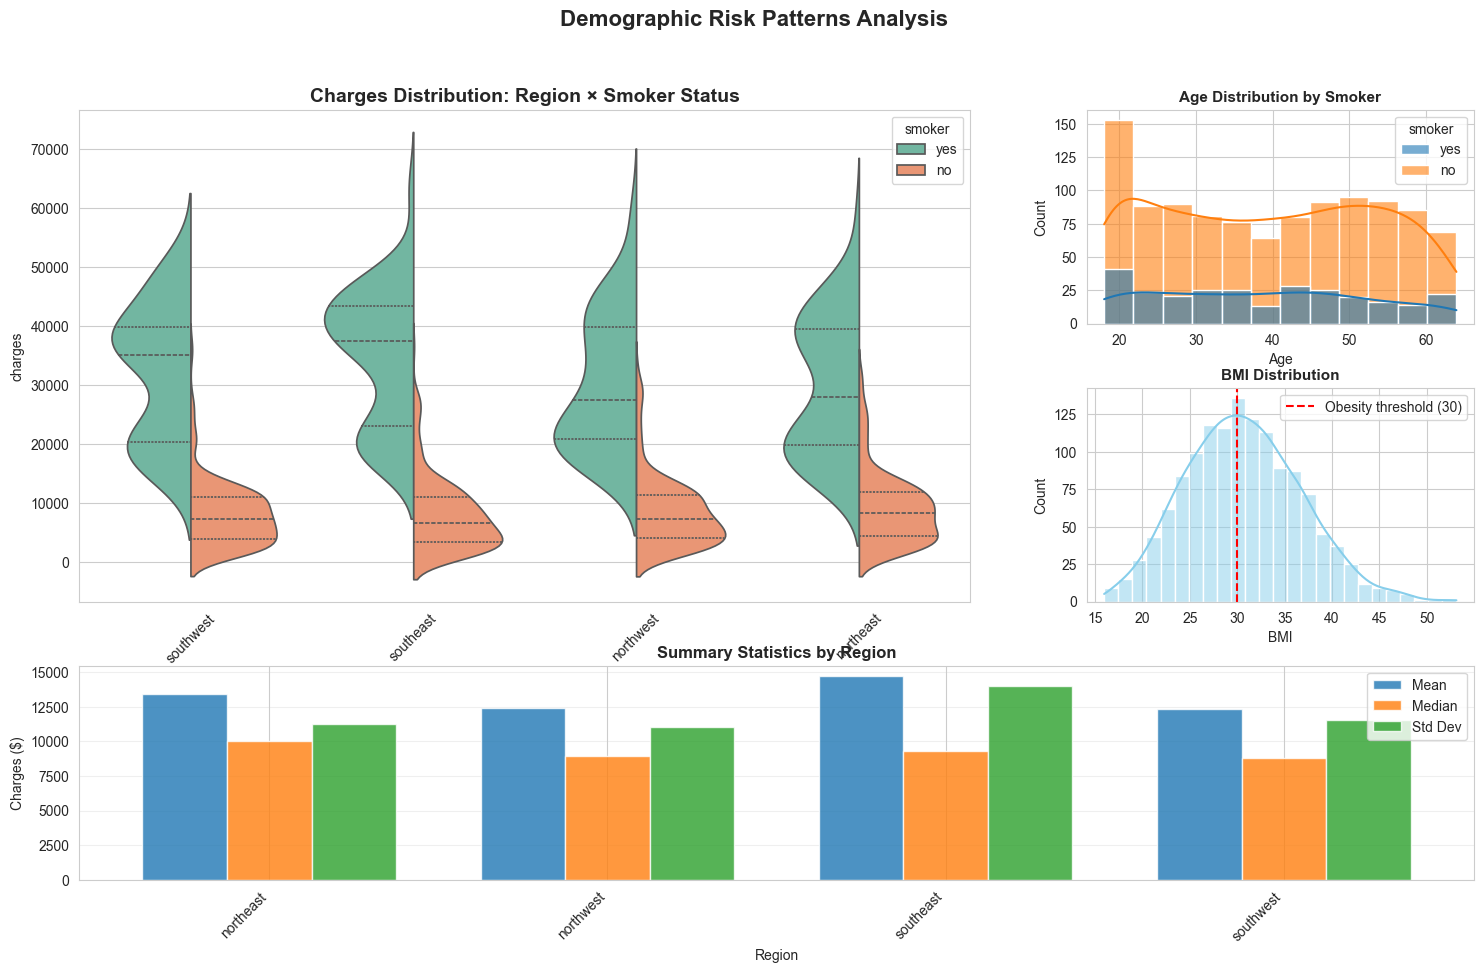

In [21]:
# CREATIVE VISUALIZATION 2: Demographic risk patterns
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Main plot: Violin plot showing distribution by multiple factors
ax_main = fig.add_subplot(gs[0:2, 0:2])
if 'region' in df.columns and 'smoker' in df.columns:
    sns.violinplot(data=df, x='region', y='charges', hue='smoker', 
                   split=True, inner='quart', ax=ax_main, palette='Set2')
    ax_main.set_title('Charges Distribution: Region × Smoker Status', 
                     fontsize=14, fontweight='bold')
    ax_main.tick_params(axis='x', rotation=45)

# Top right: Age distribution by smoker
ax_age = fig.add_subplot(gs[0, 2])
if 'age' in df.columns and 'smoker' in df.columns:
    sns.histplot(data=df, x='age', hue='smoker', kde=True, ax=ax_age, alpha=0.6)
    ax_age.set_title('Age Distribution by Smoker', fontsize=11, fontweight='bold')
    ax_age.set_xlabel('Age')
    ax_age.set_ylabel('Count')

# Middle right: BMI distribution
ax_bmi = fig.add_subplot(gs[1, 2])
if 'bmi' in df.columns:
    sns.histplot(data=df, x='bmi', kde=True, ax=ax_bmi, color='skyblue')
    ax_bmi.axvline(30, color='r', linestyle='--', label='Obesity threshold (30)')
    ax_bmi.set_title('BMI Distribution', fontsize=11, fontweight='bold')
    ax_bmi.set_xlabel('BMI')
    ax_bmi.set_ylabel('Count')
    ax_bmi.legend()

# Bottom: Summary statistics bar chart
ax_summary = fig.add_subplot(gs[2, :])
if 'region' in df.columns:
    summary_data = df.groupby('region')['charges'].agg(['mean', 'median', 'std']).reset_index()
    x = np.arange(len(summary_data))
    width = 0.25
    ax_summary.bar(x - width, summary_data['mean'], width, label='Mean', alpha=0.8)
    ax_summary.bar(x, summary_data['median'], width, label='Median', alpha=0.8)
    ax_summary.bar(x + width, summary_data['std'], width, label='Std Dev', alpha=0.8)
    ax_summary.set_xlabel('Region')
    ax_summary.set_ylabel('Charges ($)')
    ax_summary.set_title('Summary Statistics by Region', fontsize=12, fontweight='bold')
    ax_summary.set_xticks(x)
    ax_summary.set_xticklabels(summary_data['region'], rotation=45, ha='right')
    ax_summary.legend()
    ax_summary.grid(True, alpha=0.3, axis='y')

plt.suptitle('Demographic Risk Patterns Analysis', fontsize=16, fontweight='bold', y=0.98)
save_figure(fig, 'creative_viz2_demographic_patterns.png')
plt.show()


### Visualization 3: Risk Segmentation Matrix


Figure saved to: d:\kifyaAi\insurance-risk-analytics\reports\figures\creative_viz3_risk_segmentation.png


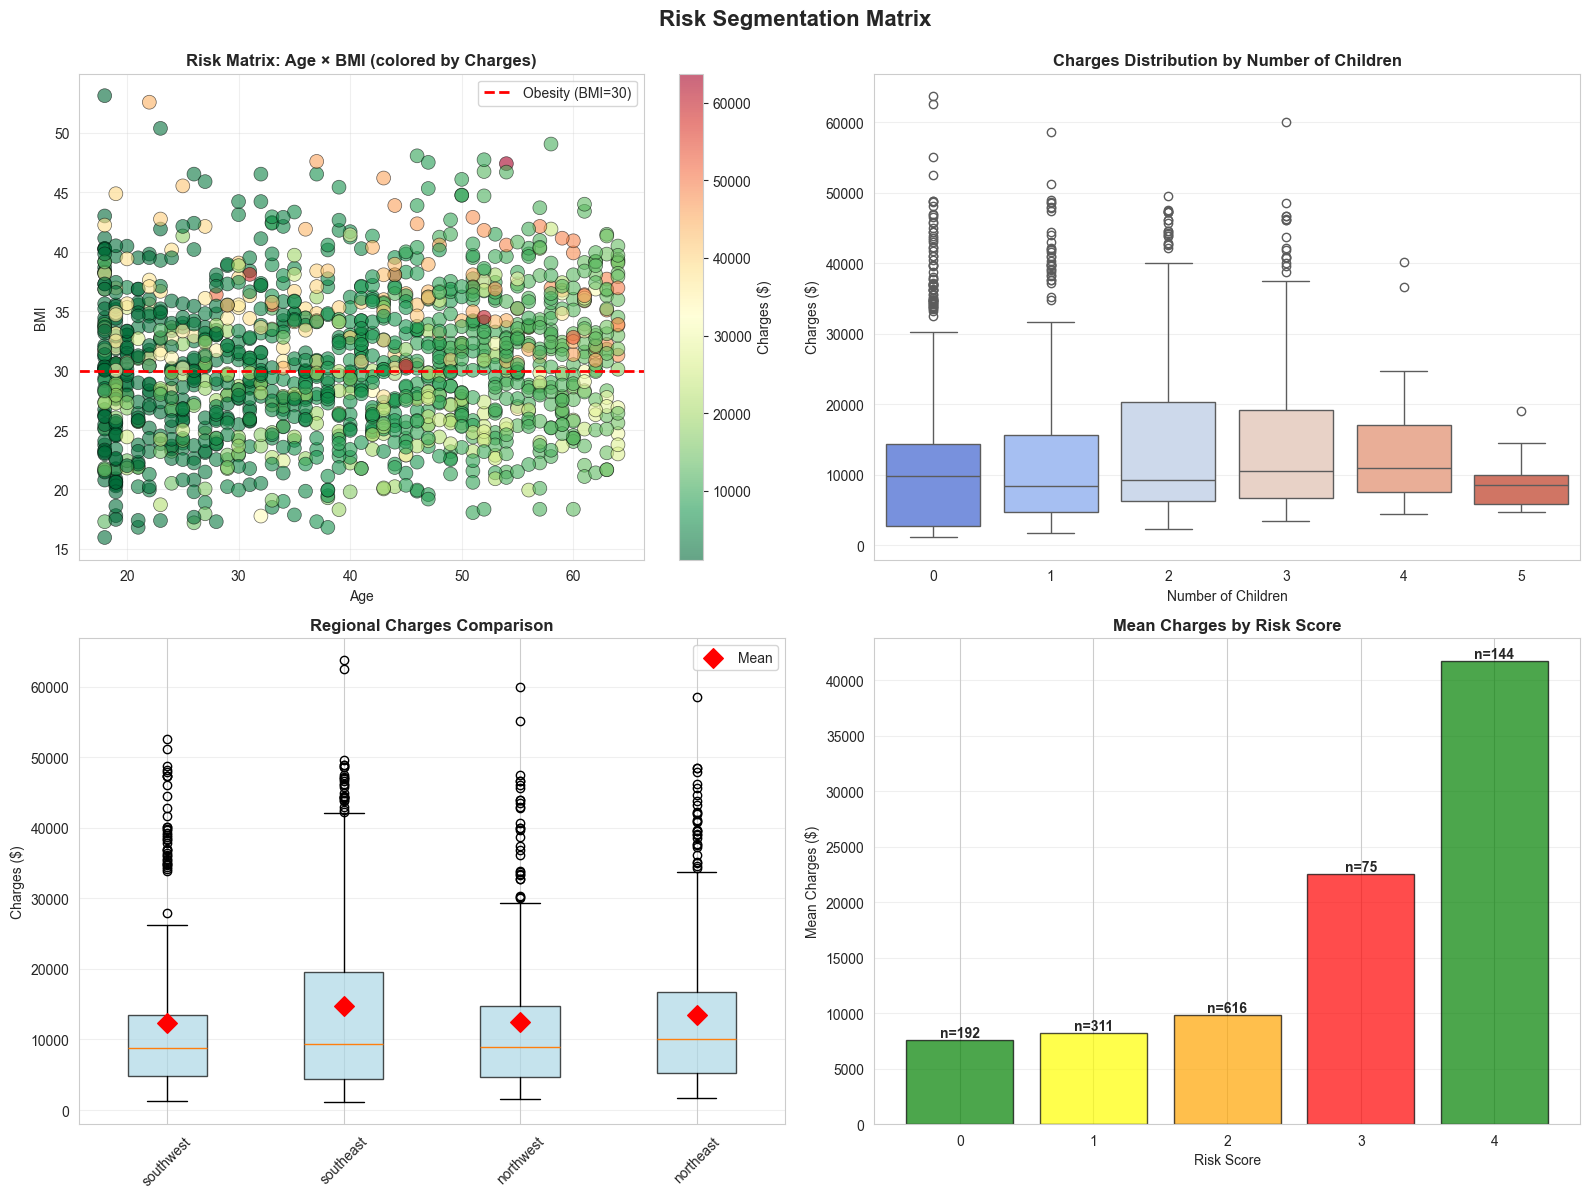

In [24]:
# CREATIVE VISUALIZATION 3: Risk segmentation matrix
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Create risk segments based on available data
if 'bmi' in df.columns and 'age' in df.columns:
    # Segment 1: Risk matrix (BMI vs Age) colored by charges
    scatter1 = axes[0, 0].scatter(df['age'], df['bmi'], 
                                  c=df['charges'], cmap='RdYlGn_r', 
                                  s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0, 0].axhline(30, color='r', linestyle='--', linewidth=2, label='Obesity (BMI=30)')
    axes[0, 0].set_xlabel('Age')
    axes[0, 0].set_ylabel('BMI')
    axes[0, 0].set_title('Risk Matrix: Age × BMI (colored by Charges)', 
                         fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0, 0], label='Charges ($)')

# Segment 2: Charges by number of children
if 'children' in df.columns:
    children_order = sorted(df['children'].unique())
    sns.boxplot(data=df, x='children', y='charges', order=children_order, 
                palette='coolwarm', ax=axes[0, 1])
    axes[0, 1].set_title('Charges Distribution by Number of Children', 
                        fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Number of Children')
    axes[0, 1].set_ylabel('Charges ($)')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

# Segment 3: Regional comparison with statistical annotations
if 'region' in df.columns:
    region_data = [df[df['region'] == region]['charges'].values 
                   for region in df['region'].unique()]
    bp = axes[1, 0].boxplot(region_data, labels=df['region'].unique(), 
                            patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    axes[1, 0].set_title('Regional Charges Comparison', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Charges ($)')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Add mean markers
    means = [np.mean(data) for data in region_data]
    axes[1, 0].scatter(range(1, len(means) + 1), means, 
                      color='red', marker='D', s=100, zorder=3, label='Mean')
    axes[1, 0].legend()

# Segment 4: Risk score visualization (if we can create a composite score)
if 'charges' in df.columns:
    # Create a simple risk score based on available factors
    df_risk = df.copy()
    if 'smoker' in df.columns:
        df_risk['smoker_score'] = df_risk['smoker'].map({'yes': 2, 'no': 0})
    else:
        df_risk['smoker_score'] = 0
    
    if 'bmi' in df.columns:
        df_risk['bmi_score'] = pd.cut(df_risk['bmi'], 
                                      bins=[0, 25, 30, 100], 
                                      labels=[0, 1, 2]).astype(int)
    else:
        df_risk['bmi_score'] = 0
    
    df_risk['risk_score'] = df_risk['smoker_score'] + df_risk['bmi_score']
    
    risk_summary = df_risk.groupby('risk_score')['charges'].agg(['mean', 'count'])
    axes[1, 1].bar(risk_summary.index, risk_summary['mean'], 
                   color=['green', 'yellow', 'orange', 'red'][:len(risk_summary)],
                   alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Risk Score')
    axes[1, 1].set_ylabel('Mean Charges ($)')
    axes[1, 1].set_title('Mean Charges by Risk Score', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Add count annotations
    for i, (idx, row) in enumerate(risk_summary.iterrows()):
        axes[1, 1].text(idx, row['mean'], f"n={int(row['count'])}", 
                       ha='center', va='bottom', fontweight='bold')

plt.suptitle('Risk Segmentation Matrix', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
save_figure(fig, 'creative_viz3_risk_segmentation.png')
plt.show()


## 10. Summary and Key Insights


In [23]:
# Generate summary insights
print("=" * 70)
print("KEY INSIGHTS SUMMARY")
print("=" * 70)

print("\n1. DATA OVERVIEW:")
print(f"   - Total records: {len(df):,}")
print(f"   - Total columns: {len(df.columns)}")
print(f"   - Missing values: {df.isnull().sum().sum()}")

print("\n2. FINANCIAL METRICS:")
if 'charges' in df.columns:
    print(f"   - Mean charges: ${df['charges'].mean():,.2f}")
    print(f"   - Median charges: ${df['charges'].median():,.2f}")
    print(f"   - Standard deviation: ${df['charges'].std():,.2f}")
    print(f"   - Range: ${df['charges'].min():,.2f} - ${df['charges'].max():,.2f}")

print("\n3. DISTRIBUTION CHARACTERISTICS:")
if 'charges' in df.columns:
    dist_info = get_distribution_info(df, 'charges')
    print(f"   - Skewness: {dist_info['skewness']:.2f} {'(Right-skewed)' if dist_info['skewness'] > 0 else '(Left-skewed)'}")
    print(f"   - Kurtosis: {dist_info['kurtosis']:.2f}")
    print(f"   - Distribution type: {'Normal' if dist_info['is_normal'] else 'Non-normal'}")

print("\n4. OUTLIER ANALYSIS:")
if 'charges' in df.columns:
    outliers, stats_dict = detect_outliers_iqr(df, 'charges')
    print(f"   - Outliers detected: {stats_dict['outlier_count']} ({stats_dict['outlier_percentage']:.2f}%)")
    print(f"   - IQR: ${stats_dict['IQR']:,.2f}")

print("\n5. GROUP DIFFERENCES:")
if 'region' in df.columns:
    region_means = df.groupby('region')['charges'].mean().sort_values(ascending=False)
    print(f"   - Highest mean charges: {region_means.index[0]} (${region_means.iloc[0]:,.2f})")
    print(f"   - Lowest mean charges: {region_means.index[-1]} (${region_means.iloc[-1]:,.2f})")
    print(f"   - Difference: ${region_means.iloc[0] - region_means.iloc[-1]:,.2f}")

if 'sex' in df.columns or 'gender' in df.columns:
    gender_col = 'sex' if 'sex' in df.columns else 'gender'
    gender_means = df.groupby(gender_col)['charges'].mean()
    print(f"   - Gender differences: {gender_means.to_dict()}")

print("\n6. CORRELATIONS:")
if len(df.select_dtypes(include=[np.number]).columns) > 1:
    corr_matrix = calculate_correlation_matrix(df)
    # Find strongest correlations
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], 
                             corr_matrix.iloc[i, j]))
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    if corr_pairs:
        print(f"   - Strongest correlation: {corr_pairs[0][0]} vs {corr_pairs[0][1]}: {corr_pairs[0][2]:.3f}")

print("\n" + "=" * 70)
print("EDA COMPLETE - Ready for further analysis and modeling")
print("=" * 70)


KEY INSIGHTS SUMMARY

1. DATA OVERVIEW:
   - Total records: 1,338
   - Total columns: 7
   - Missing values: 0

2. FINANCIAL METRICS:
   - Mean charges: $13,270.42
   - Median charges: $9,382.03
   - Standard deviation: $12,110.01
   - Range: $1,121.87 - $63,770.43

3. DISTRIBUTION CHARACTERISTICS:
   - Skewness: 1.52 (Right-skewed)
   - Kurtosis: 1.61
   - Distribution type: Non-normal

4. OUTLIER ANALYSIS:
   - Outliers detected: 139 (10.39%)
   - IQR: $11,899.63

5. GROUP DIFFERENCES:
   - Highest mean charges: southeast ($14,735.41)
   - Lowest mean charges: southwest ($12,346.94)
   - Difference: $2,388.47
   - Gender differences: {'female': 12569.578843835347, 'male': 13956.751177721893}

6. CORRELATIONS:
   - Strongest correlation: age vs charges: 0.299

EDA COMPLETE - Ready for further analysis and modeling
